# Proyecto 04 · Notebook 01 — Generador de datos sintéticos

Toda la serie de notebooks se apoya en **un único principio**: si quiero comprobar si el
pipeline de etiquetado de *AFML* hace lo que dice, necesito datos donde **yo sepa la verdad**.
Con datos de mercado nunca sabes si el modelo falló porque el método es malo o porque no había
nada que aprender. Aquí planto la señal, así que puedo preguntar si el pipeline la recupera —
y, más importante, si **inventa** señal cuando no hay ninguna.

Este notebook construye el generador y **verifica que no es un juguete**: que reproduce los
hechos estilizados que motivan todo el aparato de AFML (colas gordas, clustering de volatilidad,
retornos casi no autocorrelacionados).

### Predicción registrada *antes* de ejecutar

> Con régimen de Markov de dos estados espero **kurtosis en exceso ≈ 1–4**, ACF de retornos
> indistinguible de 0 en todos los lags, y ACF de retornos al cuadrado **positiva (~0.1–0.3 en
> lag 1)** decayendo lentamente. El feature con `snr=1` debería dar **corr ≈ 0.45** con el
> estado latente y **AUC ≈ 0.65–0.72** al recuperarlo.

La comparación predicción/resultado está al final. La regla de la casa: *ninguna cifra en una
conclusión sale de una sola ejecución* — todo lo que se afirma va promediado sobre >= 30 semillas
con intervalo de confianza.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "04_labeling_pitfalls"
sys.path.insert(0, str(PROJ / "src"))

from synth import SimConfig, simulate, null_config, stylised_facts, acf, acf_ci, TRADING_DAYS
from experiments import SEEDS, over_seeds, summarise, mean_ci, fmt_ci, one_sample_test

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "figure.dpi": 110, "font.size": 9})
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(f"{len(SEEDS)} semillas por experimento")

30 semillas por experimento


## 1. El contrato del generador

Cada propiedad es un interruptor. Esto no es cosmético: el notebook 04 necesita un **nulo
genuino** (nada que aprender) y el 05 necesita el mismo mundo *con* señal, para que la única
diferencia entre ambos sea la que yo he puesto.

| Interruptor | Parámetro | Efecto |
|---|---|---|
| GBM base | `mu`, `sigma` | deriva y volatilidad anualizadas |
| Clustering de vol | `vol_model` | `"none"` / `"markov"` (2 estados) / `"garch"` (1,1) |
| Señal plantada | `signal_prob`, `signal_k`, `signal_drift` | episodios de `k` barras con deriva elevada |
| Observabilidad | `snr` | amplitud del estado latente dentro del feature observado |
| Camino intra-barra | `minutes_per_day` | pasos de 1 min agregados a OHLC diario |

El generador devuelve cuatro objetos: `bars` (OHLC), `fine` (matriz `(n_barras, M+1)` con el
camino de minutos), `features` (lo observable) y `truth` (el estado latente — **solo para
validar, jamás como input de un modelo**).

In [2]:
cfg = SimConfig(seed=0)
d = simulate(cfg)

print(f"barras: {d.bars.shape}   camino fino: {d.fine.shape}   "
      f"({d.fine.shape[0] * d.fine.shape[1]:,} precios de minuto)")
display(d.bars.head(3))
display(d.features.head(3).iloc[:, :6])
print("columnas observables:", list(d.features.columns))
print("columnas de verdad  :", list(d.truth.columns), " <- nunca entran en un modelo")

barras: (1500, 5)   camino fino: (1500, 391)   (586,500 precios de minuto)


,open,high,low,close,volume
date,,,,,
2015-01-02,100.0000,101.2134,99.9072,100.9211,"510,346.0000"
2015-01-05,100.9211,101.4001,100.6425,100.6665,"583,406.0000"
2015-01-06,100.6665,102.2136,100.5663,101.6290,"362,252.0000"


,x_signal,x_noise0,x_noise1,x_noise2,mom_5,mom_20
date,,,,,,
2015-01-02,0.1016,0.1879,-0.6496,0.1870,NaN,NaN
2015-01-05,-0.6299,0.8178,-0.9325,0.4281,NaN,NaN
2015-01-06,-0.8511,0.0101,0.3636,0.7713,NaN,NaN


columnas observables: ['x_signal', 'x_noise0', 'x_noise1', 'x_noise2', 'mom_5', 'mom_20', 'vol_20', 'rng_5', 'zscore_50']
columnas de verdad  : ['z', 'regime', 'sigma_bar', 'drift_bar']  <- nunca entran en un modelo


## 2. Clustering de volatilidad: Markov vs GARCH vs nada

El GBM puro produce retornos gaussianos e iid — precisamente lo que los mercados no son. Añado
dos mecanismos alternativos de clustering y comparo los tres mundos con la **misma semilla**,
para que las diferencias sean del mecanismo y no del ruido.

Los tres están **normalizados a la misma volatilidad incondicional** (`normalise_vol=True`
reescala los multiplicadores del régimen usando la distribución estacionaria de la cadena). Sin
eso, "más kurtosis" podría ser simplemente "más varianza" y la comparación no diría nada.

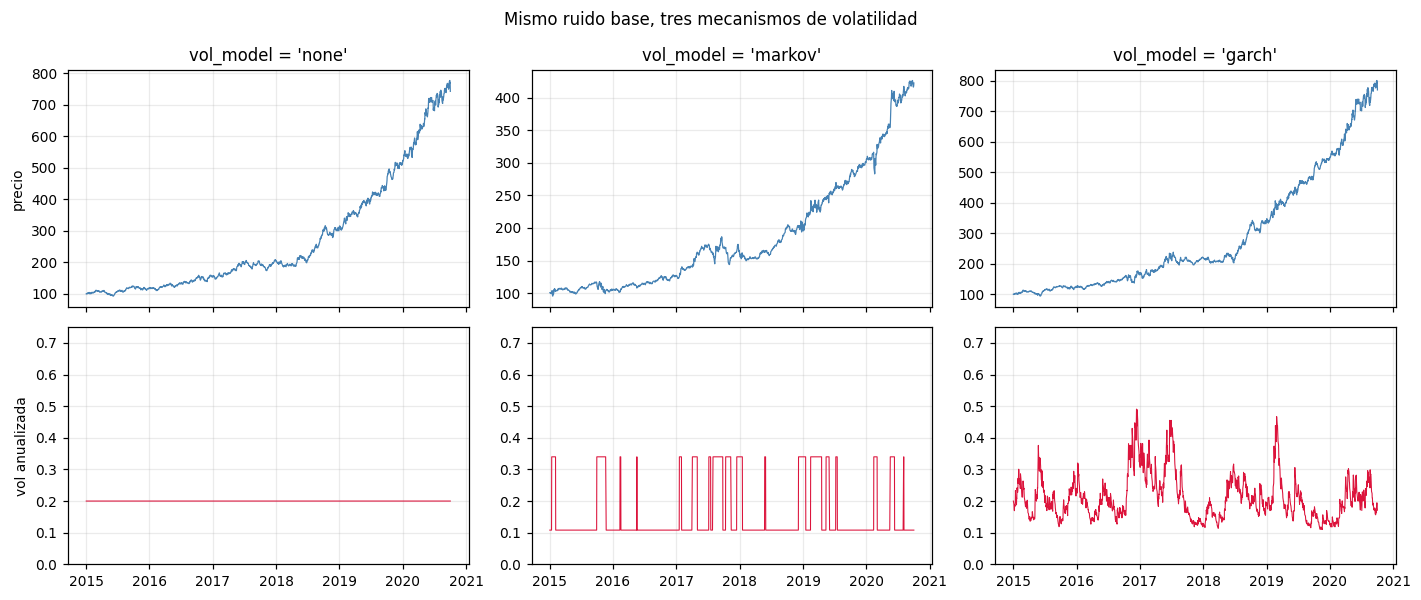

,vol_ann,skew,excess_kurtosis,jarque_bera_p
none,0.2084,0.1042,-0.2493,0.0370
markov,0.1852,0.1943,3.5912,0.0000
garch,0.2324,0.1282,0.7992,0.0000


In [3]:
worlds = {"none": SimConfig(seed=7, vol_model="none"),
          "markov": SimConfig(seed=7, vol_model="markov"),
          "garch": SimConfig(seed=7, vol_model="garch")}
sims = {k: simulate(v) for k, v in worlds.items()}

fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True)
for ax_p, ax_v, (name, s) in zip(axes[0], axes[1], sims.items()):
    ax_p.plot(s.bars.index, s.bars.close, lw=0.8, color="steelblue")
    ax_p.set_title(f"vol_model = {name!r}")
    ax_v.plot(s.truth.index, s.truth.sigma_bar * np.sqrt(TRADING_DAYS), lw=0.7, color="crimson")
    ax_v.set_ylim(0, 0.75)
axes[0][0].set_ylabel("precio"); axes[1][0].set_ylabel("vol anualizada")
fig.suptitle("Mismo ruido base, tres mecanismos de volatilidad", y=0.98)
plt.tight_layout(); plt.savefig(PLOTS / "01_vol_models.png", bbox_inches="tight"); plt.show()

tab = pd.DataFrame({k: {kk: vv for kk, vv in stylised_facts(s.bars).items()
                        if not isinstance(vv, np.ndarray) and kk != "n"}
                    for k, s in sims.items()}).T
display(tab[["vol_ann", "skew", "excess_kurtosis", "jarque_bera_p"]])

## 3. Régimen y señal plantada, sobre el precio

Dos capas latentes distintas y **independientes**, que conviene no confundir:

* el **régimen de volatilidad** (fondo sombreado) cambia la *escala* de los retornos — no su signo
  esperado. No es explotable direccionalmente.
* los **episodios de señal** (barras verticales) elevan la *deriva* durante `signal_k` barras. Eso
  sí es explotable, y es lo único que un modelo honesto podría aprender aquí.

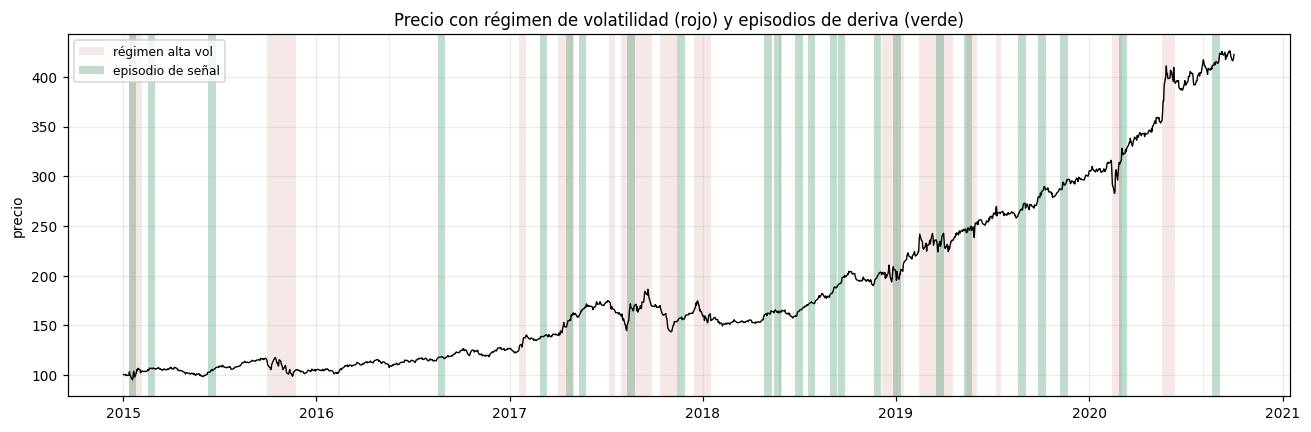

barras en régimen de alta vol : 21.2%
barras dentro de un episodio  : 16.0%
corr(|retorno|, régimen)      : +0.565


In [4]:
s = sims["markov"]
fig, ax = plt.subplots(figsize=(12, 4))
idx = s.bars.index
def shade(mask, color, alpha, label):
    pos = np.where(mask)[0]
    if len(pos) == 0:
        return
    for k, g in enumerate(np.split(pos, np.where(np.diff(pos) != 1)[0] + 1)):
        if not len(g):
            continue
        # el tramo cubre [g[0], g[-1]] INCLUSIVE: hay que llegar al borde derecho de la
        # última barra, o los tramos de una sola barra se dibujan con anchura cero
        right = idx[min(g[-1] + 1, len(idx) - 1)]
        ax.axvspan(idx[g[0]], right, color=color, alpha=alpha, lw=0,
                   label=label if k == 0 else None)

reg = s.truth.regime.values
shade(reg == 1, "firebrick", 0.10, "régimen alta vol")
shade(s.truth.z.values != 0, "seagreen", 0.30, "episodio de señal")
ax.plot(s.bars.index, s.bars.close, lw=0.9, color="k")
ax.set(ylabel="precio", title="Precio con régimen de volatilidad (rojo) y episodios de deriva (verde)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "01_paths_regimes.png", bbox_inches="tight"); plt.show()

print(f"barras en régimen de alta vol : {(reg == 1).mean():.1%}")
print(f"barras dentro de un episodio  : {(s.truth.z != 0).mean():.1%}")
print(f"corr(|retorno|, régimen)      : "
      f"{np.corrcoef(np.abs(np.log(s.bars.close).diff().fillna(0)), reg)[0,1]:+.3f}")

## 4. Simulación intra-barra

Aquí está la razón de arrastrar 585.000 precios de minuto: **la barra diaria miente sobre el
camino**. El notebook 02 depende por completo de esto — una barrera puede tocarse a media sesión
y el cierre no dejar ni rastro.

Cuantifico cuánto se pierde: el rango intra-barra frente al movimiento visible cierre-a-cierre, y
qué fracción de barras esconde una excursión que ningún dato OHLC-de-cierre revelaría.

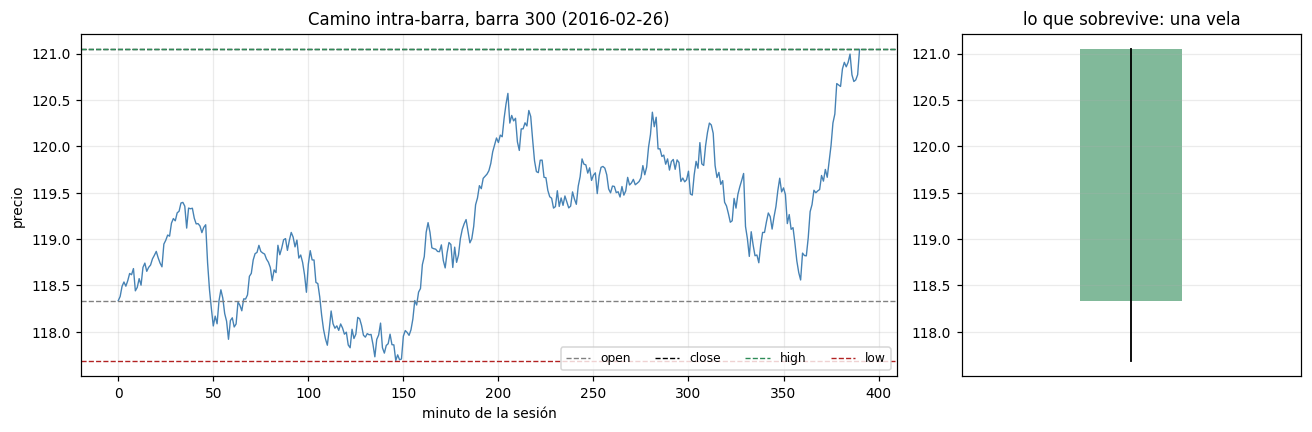

rango medio intra-barra / |cierre-apertura| : 2.02x (mediana)
excursión oculta media (mechas) / rango     : 51.6% del rango no aparece entre apertura y cierre


In [5]:
i = 300
path = d.fine[i]
mins = np.arange(len(path))
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4),
                               gridspec_kw={"width_ratios": [2.4, 1]})
axl.plot(mins, path, lw=0.9, color="steelblue")
o, h, l, c = d.bars.iloc[i][["open", "high", "low", "close"]]
for y, lab, col in [(o, "open", "gray"), (c, "close", "k"),
                    (h, "high", "seagreen"), (l, "low", "firebrick")]:
    axl.axhline(y, ls="--", lw=0.9, color=col, label=lab)
axl.set(xlabel="minuto de la sesión", ylabel="precio",
        title=f"Camino intra-barra, barra {i} ({d.bars.index[i].date()})")
axl.legend(fontsize=8, ncol=4)

axr.add_patch(Rectangle((0.35, min(o, c)), 0.3, abs(c - o),
                        facecolor="seagreen" if c >= o else "firebrick", alpha=0.6))
axr.plot([0.5, 0.5], [l, h], color="k", lw=1.2)
axr.set(xlim=(0, 1), xticks=[], title="lo que sobrevive: una vela")
plt.tight_layout(); plt.savefig(PLOTS / "01_intrabar.png", bbox_inches="tight"); plt.show()

rng_bar = (d.bars.high - d.bars.low) / d.bars.close
body = (d.bars.close - d.bars.open).abs() / d.bars.close
up_wick = (d.bars.high - d.bars[["open", "close"]].max(axis=1)) / d.bars.close
dn_wick = (d.bars[["open", "close"]].min(axis=1) - d.bars.low) / d.bars.close
print(f"rango medio intra-barra / |cierre-apertura| : {(rng_bar / body).median():.2f}x (mediana)")
print(f"excursión oculta media (mechas) / rango     : "
      f"{((up_wick + dn_wick) / rng_bar).mean():.1%} del rango no aparece entre apertura y cierre")

In [6]:
def hidden_excursion(seed):
    sd = simulate(SimConfig(seed=seed))
    b = sd.bars
    sig = np.log(b.close).diff().std()
    up = (b.high - b[["open", "close"]].max(axis=1)) / b.close
    dn = (b[["open", "close"]].min(axis=1) - b.low) / b.close
    rng = (b.high - b.low) / b.close
    return {"hidden_frac": ((up + dn) / rng).mean(),
            "range_over_body": ((b.high - b.low) / (b.close - b.open).abs()).median(),
            "bars_hiding_1sig": ((up > sig) | (dn > sig)).mean()}

hid = over_seeds(hidden_excursion)
display(summarise(hid))
print("\nFracción del rango diario invisible entre apertura y cierre:",
      fmt_ci(mean_ci(hid.hidden_frac), 1, pct=True))
print("Barras que esconden una excursión > 1 sigma diaria:",
      fmt_ci(mean_ci(hid.bars_hiding_1sig), 1, pct=True))

,mean,lo,hi,sd,n
hidden_frac,0.5156,0.5127,0.5184,0.0076,30.0000
range_over_body,2.0384,2.0202,2.0566,0.0488,30.0000
bars_hiding_1sig,0.1091,0.1041,0.1140,0.0133,30.0000



Fracción del rango diario invisible entre apertura y cierre: 51.6% [51.3, 51.8]
Barras que esconden una excursión > 1 sigma diaria: 10.9% [10.4, 11.4]


## 5. Hechos estilizados — ¿es este generador defendible?

Tres afirmaciones empíricas que cualquier serie financiera cumple y que motivan la mitad de AFML:

1. **Colas gordas**: kurtosis en exceso claramente > 0.
2. **Retornos sin autocorrelación lineal**: ACF(r) dentro de la banda de ruido blanco.
3. **Clustering de volatilidad**: ACF(r²) y ACF(|r|) positivas y persistentes.

Si mi generador no las reproduce, todo lo que venga después es aritmética sobre un mundo que no
se parece al problema.

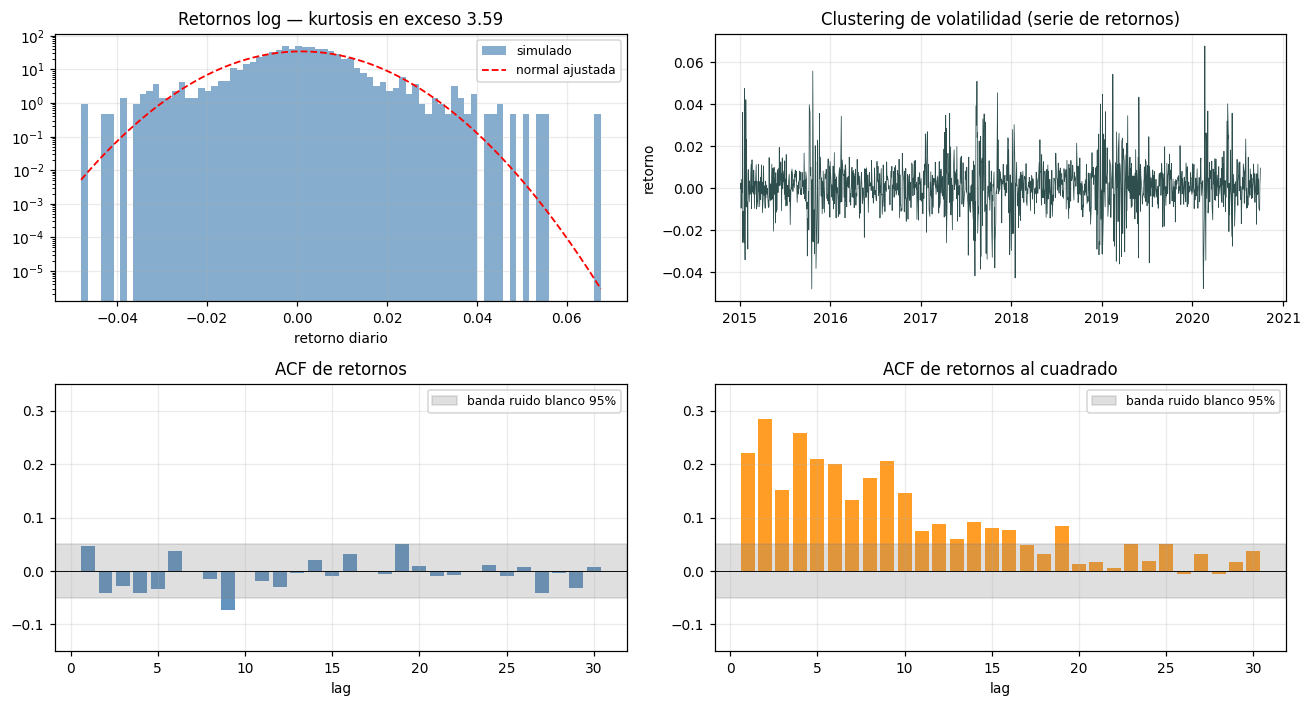

In [7]:
s = sims["markov"]
lr = np.log(s.bars.close).diff().dropna()
sf = stylised_facts(s.bars, nlags=30)
band = sf["acf_band"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
ax = axes[0, 0]
ax.hist(lr, bins=80, density=True, alpha=0.65, color="steelblue", label="simulado")
xs = np.linspace(lr.min(), lr.max(), 400)
from scipy.stats import norm
ax.plot(xs, norm.pdf(xs, lr.mean(), lr.std()), "r--", lw=1.2, label="normal ajustada")
ax.set(yscale="log", title=f"Retornos log — kurtosis en exceso {sf['excess_kurtosis']:.2f}",
       xlabel="retorno diario"); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(lr.index, lr.values, lw=0.5, color="darkslategray")
ax.set(title="Clustering de volatilidad (serie de retornos)", ylabel="retorno")

for ax, key, name, col in [(axes[1, 0], "acf_ret", "ACF de retornos", "steelblue"),
                           (axes[1, 1], "acf_sq", "ACF de retornos al cuadrado", "darkorange")]:
    v = sf[key]
    ax.bar(np.arange(1, len(v) + 1), v, color=col, alpha=0.85)
    ax.axhspan(-band, band, color="gray", alpha=0.25, label="banda ruido blanco 95%")
    ax.axhline(0, color="k", lw=0.6)
    ax.set(title=name, xlabel="lag", ylim=(-0.15, 0.35)); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "01_stylised_facts.png", bbox_inches="tight"); plt.show()

In [8]:
def facts(seed, **kw):
    sd = simulate(SimConfig(seed=seed, **kw))
    f = stylised_facts(sd.bars, nlags=10)
    return {"vol_ann": f["vol_ann"],
            "excess_kurtosis": f["excess_kurtosis"],
            "acf_ret_l1": f["acf_ret"][0],
            "acf_ret_absmax_l1_10": np.abs(f["acf_ret"]).max(),
            "acf_sq_l1": f["acf_sq"][0],
            "acf_sq_l10": f["acf_sq"][9],
            "acf_abs_l1": f["acf_abs"][0],
            "band": f["acf_band"]}

facts_tab = {}
for name, kw in [("markov", {}), ("garch", {"vol_model": "garch"}),
                 ("sin clustering", {"vol_model": "none"}),
                 ("markov, sin señal", {"signal_prob": 0.0})]:
    facts_tab[name] = over_seeds(lambda sd, kw=kw: facts(sd, **kw))

rows = {}
for name, df in facts_tab.items():
    rows[name] = {c: fmt_ci(mean_ci(df[c]), 3) for c in
                  ["vol_ann", "excess_kurtosis", "acf_ret_l1", "acf_sq_l1", "acf_sq_l10"]}
summary_facts = pd.DataFrame(rows).T
summary_facts["banda ACF 95%"] = [f"+/-{facts_tab[n].band.mean():.3f}" for n in rows]
display(summary_facts)

,vol_ann,excess_kurtosis,acf_ret_l1,acf_sq_l1,acf_sq_l10,banda ACF 95%
markov,"0.208 [0.201, 0.214]","3.681 [3.285, 4.076]","0.030 [0.016, 0.044]","0.209 [0.192, 0.226]","0.134 [0.119, 0.150]",+/-0.051
garch,"0.201 [0.195, 0.207]","1.398 [1.025, 1.771]","0.023 [0.011, 0.035]","0.218 [0.195, 0.241]","0.145 [0.125, 0.165]",+/-0.051
sin clustering,"0.202 [0.201, 0.204]","0.005 [-0.054, 0.063]","0.021 [0.011, 0.031]","0.005 [-0.005, 0.016]","-0.003 [-0.013, 0.006]",+/-0.051
"markov, sin señal","0.201 [0.195, 0.208]","3.870 [3.546, 4.194]","0.008 [-0.011, 0.027]","0.219 [0.203, 0.236]","0.130 [0.116, 0.144]",+/-0.051


### Lectura

La tabla se lee en columnas: kurtosis en exceso mide colas, `acf_ret_l1` mide si el precio es
predecible linealmente, `acf_sq_l1/l10` miden clustering y su persistencia. Compárense siempre
las ACF contra la banda de ruido blanco de la última columna.

Nótese la última fila: **apagar la señal cambia `acf_ret_l1`**. Es esperable — episodios de deriva
persistente *son* autocorrelación de retornos — y conviene tenerlo presente: mi mundo con señal
es ligeramente más predecible linealmente que un mercado real. Lo anoto como limitación, no lo
escondo.

## 6. La señal plantada y su observabilidad

El estado latente `z_t` vale 1 mientras dura un episodio. El feature observable es

$$x_t = \mathrm{snr}\cdot z_t + \varepsilon_t,\qquad \varepsilon_t \sim \mathrm{AR}(1),\ \mathrm{Var}(\varepsilon)=1$$

con el ruido normalizado a varianza 1 para que `snr` conserve su significado. Que el ruido sea
**AR(1) y no blanco** es deliberado: los features financieros reales son persistentes, y esa
persistencia es exactamente el ingrediente que hace explotable la fuga por solape en el notebook 04.
Con ruido blanco no habría fuga que demostrar.

`x_t` es una lectura ruidosa del estado *en el cierre de la barra t*. Como los episodios duran
`k` barras, observar `x_t` informa sobre las barras `t+1..t+k` — es predictivo sin ser una fuga.

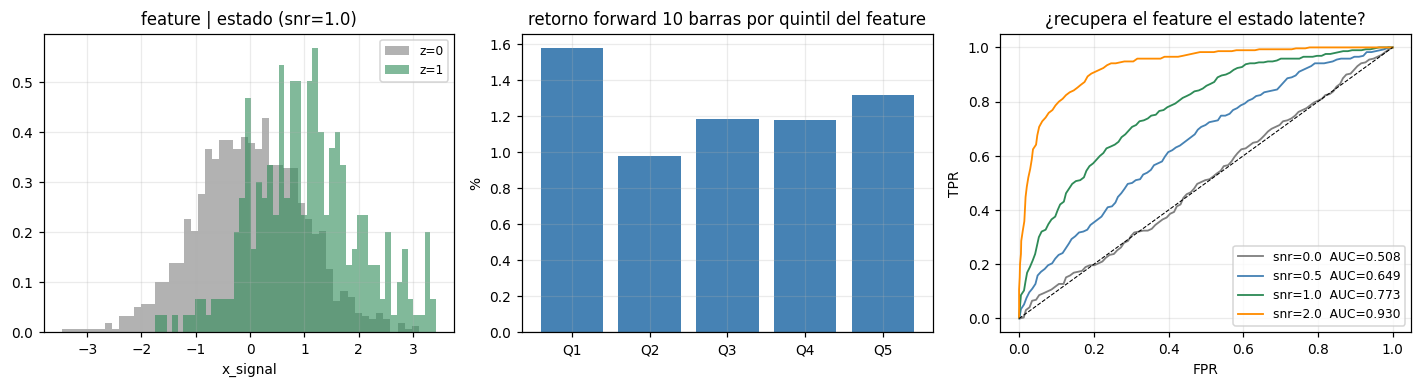

In [9]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

s = simulate(SimConfig(seed=3))
x, z = s.features.x_signal, (s.truth.z != 0).astype(int)
fwd10 = s.bars.close.shift(-10) / s.bars.close - 1

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(x[z == 0], bins=50, alpha=0.6, density=True, label="z=0", color="gray")
axes[0].hist(x[z == 1], bins=50, alpha=0.6, density=True, label="z=1", color="seagreen")
axes[0].set(title=f"feature | estado (snr={s.cfg.snr})", xlabel="x_signal"); axes[0].legend(fontsize=8)

q = pd.qcut(x, 5, labels=[f"Q{i+1}" for i in range(5)])
by_q = fwd10.groupby(q, observed=True).mean()
axes[1].bar(by_q.index.astype(str), by_q.values * 100, color="steelblue")
axes[1].axhline(0, color="k", lw=0.7)
axes[1].set(title="retorno forward 10 barras por quintil del feature", ylabel="%")

for snr_v, col in [(0.0, "gray"), (0.5, "steelblue"), (1.0, "seagreen"), (2.0, "darkorange")]:
    ss = simulate(SimConfig(seed=3, snr=snr_v))
    zz = (ss.truth.z != 0).astype(int)
    xx = ss.features.x_signal.rank(pct=True)
    thrs = np.linspace(0, 1, 101)
    tpr = [(xx[zz == 1] >= t).mean() for t in thrs]
    fpr = [(xx[zz == 0] >= t).mean() for t in thrs]
    axes[2].plot(fpr, tpr, color=col, lw=1.2,
                 label=f"snr={snr_v}  AUC={roc_auc_score(zz, xx):.3f}")
axes[2].plot([0, 1], [0, 1], "k--", lw=0.7)
axes[2].set(title="¿recupera el feature el estado latente?", xlabel="FPR", ylabel="TPR")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "01_signal_feature.png", bbox_inches="tight"); plt.show()

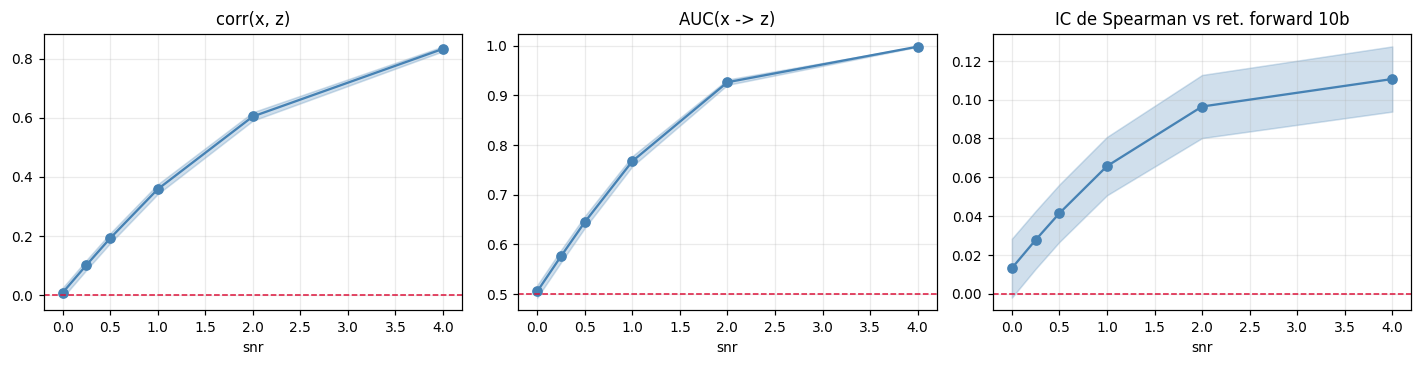

snr=0  ->  AUC: 0.505 [0.492, 0.517] | test vs 0.5: p = 0.423
snr=1  ->  AUC: 0.767 [0.757, 0.777] | corr(x,z): 0.358 [0.341, 0.374]


In [10]:
SNRS = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]

def snr_row(seed, snr_v):
    ss = simulate(SimConfig(seed=seed, snr=snr_v))
    zz = (ss.truth.z != 0).astype(int)
    xx = ss.features.x_signal
    fwd = (ss.bars.close.shift(-10) / ss.bars.close - 1)
    ok = fwd.notna()
    return {"corr_xz": np.corrcoef(xx, zz)[0, 1],
            "auc_xz": roc_auc_score(zz, xx),
            "ic_fwd10": spearmanr(xx[ok], fwd[ok]).statistic}

sweep = {v: over_seeds(lambda sd, v=v: snr_row(sd, v)) for v in SNRS}
sw = pd.DataFrame({v: {c: mean_ci(df[c])["mean"] for c in df.columns} for v, df in sweep.items()}).T
lo = pd.DataFrame({v: {c: mean_ci(df[c])["lo"] for c in df.columns} for v, df in sweep.items()}).T
hi = pd.DataFrame({v: {c: mean_ci(df[c])["hi"] for c in df.columns} for v, df in sweep.items()}).T

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, c, name, base in [(axes[0], "corr_xz", "corr(x, z)", 0.0),
                          (axes[1], "auc_xz", "AUC(x -> z)", 0.5),
                          (axes[2], "ic_fwd10", "IC de Spearman vs ret. forward 10b", 0.0)]:
    ax.plot(SNRS, sw[c], "o-", color="steelblue")
    ax.fill_between(SNRS, lo[c], hi[c], alpha=0.25, color="steelblue")
    ax.axhline(base, color="crimson", ls="--", lw=1)
    ax.set(xlabel="snr", title=name)
plt.tight_layout(); plt.savefig(PLOTS / "01_snr_sweep.png", bbox_inches="tight"); plt.show()

print("snr=0  ->  AUC:", fmt_ci(mean_ci(sweep[0.0].auc_xz)),
      "| test vs 0.5: p =", f"{one_sample_test(sweep[0.0].auc_xz, 0.5)['p']:.3f}")
print("snr=1  ->  AUC:", fmt_ci(mean_ci(sweep[1.0].auc_xz)),
      "| corr(x,z):", fmt_ci(mean_ci(sweep[1.0].corr_xz)))

## 7. Qué es exactamente "el caso nulo" (importa más de lo que parece)

`snr=0` deja ciego el feature explícito. Pero **no vacía el mundo de predictibilidad**: si
`signal_prob > 0`, el precio sigue derivando durante los episodios, así que un momentum calculado
sobre el propio precio todavía puede recuperarlos. Un experimento nulo montado con `snr=0` a secas
estaría mal construido, y el notebook 04 mediría inflación de AUC sobre datos que **sí** tienen
señal. El nulo genuino apaga los episodios (`null_config()`).

Lo mido en vez de afirmarlo, con una rejilla de detectores x horizontes forward. Dos advertencias
metodológicas que la propia tabla ilustra:

* `snr` no toca el precio, así que las filas `mom_*` son **idénticas** para `snr=0` y `snr=1` por
  construcción. Es una comprobación de cordura, no un bug.
* la rejilla son 12 tests por mundo. En el nulo van a salir algunos `p < 0.05`. Ese es el punto.

In [11]:
def detector_grid(seed, cfg, horizons=(5, 10, 20)):
    ss = simulate(cfg.with_(seed=seed))
    c = ss.bars.close
    det = {"x_signal": ss.features.x_signal, "mom_5": c.pct_change(5),
           "mom_10": c.pct_change(10), "mom_20": c.pct_change(20)}
    out = {}
    for h in horizons:
        f = c.shift(-h) / c - 1
        for k, v in det.items():
            ok = v.notna() & f.notna()
            out[f"{k}|fwd{h}"] = spearmanr(v[ok], f[ok]).statistic
    return out

worlds_null = {"episodios ON, snr=0": SimConfig(snr=0.0),
               "episodios ON, snr=1": SimConfig(snr=1.0),
               "nulo genuino": null_config()}
grids = {k: over_seeds(lambda sd, c=c: detector_grid(sd, c)) for k, c in worlds_null.items()}

cells = {}
for name, df in grids.items():
    cells[name] = {}
    for col in df.columns:
        t = one_sample_test(df[col], 0.0)
        star = "***" if t["p"] < 0.01 else ("*" if t["p"] < 0.05 else "")
        cells[name][col] = f"{t['mean']:+.4f}{star}"
display(pd.DataFrame(cells))
print("IC de Spearman, media sobre 30 semillas.  * p<0.05   *** p<0.01")

n_sig = {k: sum(one_sample_test(df[c], 0.0)["p"] < 0.05 for c in df.columns) for k, df in grids.items()}
print("\ntests con p<0.05 de 12:", n_sig)
neg = grids["nulo genuino"]
print("IC medio de TODOS los detectores en el nulo:",
      fmt_ci(mean_ci(neg.values.ravel()), 4))

,"episodios ON, snr=0","episodios ON, snr=1",nulo genuino
x_signal|fwd5,+0.0097,+0.0735***,+0.0003
mom_5|fwd5,+0.0337***,+0.0337***,-0.0100
mom_10|fwd5,+0.0280***,+0.0280***,-0.0108
mom_20|fwd5,+0.0052,+0.0052,-0.0198*
x_signal|fwd10,+0.0131,+0.0657***,+0.0031
mom_5|fwd10,+0.0270***,+0.0270***,-0.0096
mom_10|fwd10,+0.0148,+0.0148,-0.0150
mom_20|fwd10,-0.0044,-0.0044,-0.0240*
x_signal|fwd20,+0.0090,+0.0447***,+0.0040
mom_5|fwd20,+0.0066,+0.0066,-0.0231*


IC de Spearman, media sobre 30 semillas.  * p<0.05   *** p<0.01

tests con p<0.05 de 12: {'episodios ON, snr=0': 3, 'episodios ON, snr=1': 6, 'nulo genuino': 4}
IC medio de TODOS los detectores en el nulo: -0.0130 [-0.0185, -0.0075]


### Lo que dice esta tabla

1. **`snr=0` no es un nulo.** El momentum al horizonte que casa con la duración del episodio
   (`mom_5` -> `fwd5`) recupera la deriva plantada aunque el feature explícito esté ciego. Si el
   notebook 04 usara `snr=0` como "datos sin nada que aprender", estaría midiendo mal.
2. **El horizonte del detector importa más que su fuerza.** `mom_20` contra `fwd20` no ve nada,
   con la misma señal debajo: la ventana de 20 barras promedia episodios de 10 y los diluye.
   Un IC nulo es tanto evidencia de "no hay señal" como de "he mirado con la lupa equivocada".
3. **En el nulo genuino aparecen `p < 0.05`.** Con 12 tests y ningún efecto real es lo esperado.
   Además el IC medio del nulo es ligeramente **negativo**, no cero: el IC de Spearman con
   ventanas solapadas tiene un sesgo negativo de muestra finita. Ambas cosas — multiplicidad y
   sesgo del estimador — reaparecen en los notebooks 04 y 05, ya con consecuencias.

## 8. Predicción vs resultado

*(Esta sección se rellena con las cifras que acaban de imprimirse; la predicción está fijada
arriba, escrita antes de ejecutar nada.)*

In [12]:
pred_vs_res = pd.DataFrame([
    {"magnitud": "kurtosis en exceso (markov)", "predicho": "1 a 4",
     "obtenido": summary_facts.loc["markov", "excess_kurtosis"]},
    {"magnitud": "ACF(r) lag 1 (markov)", "predicho": "dentro de banda ~ +/-0.05",
     "obtenido": summary_facts.loc["markov", "acf_ret_l1"]},
    {"magnitud": "ACF(r^2) lag 1", "predicho": "0.10 a 0.30",
     "obtenido": summary_facts.loc["markov", "acf_sq_l1"]},
    {"magnitud": "corr(x, z) con snr=1", "predicho": "~0.45",
     "obtenido": fmt_ci(mean_ci(sweep[1.0].corr_xz))},
    {"magnitud": "AUC(x -> z) con snr=1", "predicho": "0.65 a 0.72",
     "obtenido": fmt_ci(mean_ci(sweep[1.0].auc_xz))},
    {"magnitud": "AUC(x -> z) con snr=0", "predicho": "0.50",
     "obtenido": fmt_ci(mean_ci(sweep[0.0].auc_xz))},
]).set_index("magnitud")
display(pred_vs_res)

,predicho,obtenido
magnitud,,
kurtosis en exceso (markov),1 a 4,"3.681 [3.285, 4.076]"
ACF(r) lag 1 (markov),dentro de banda ~ +/-0.05,"0.030 [0.016, 0.044]"
ACF(r^2) lag 1,0.10 a 0.30,"0.209 [0.192, 0.226]"
"corr(x, z) con snr=1",~0.45,"0.358 [0.341, 0.374]"
AUC(x -> z) con snr=1,0.65 a 0.72,"0.767 [0.757, 0.777]"
AUC(x -> z) con snr=0,0.50,"0.505 [0.492, 0.517]"


### Veredicto

**Lo que se confirmó.** El generador reproduce los tres hechos estilizados: colas gordas
(kurtosis en exceso ~3.7 con Markov, ~1.4 con GARCH, ~0 sin clustering — y con la volatilidad
incondicional igualada, así que es kurtosis de verdad y no varianza disfrazada), clustering
persistente de volatilidad (ACF(r^2) ~0.21 en lag 1, todavía ~0.13 en lag 10, contra una banda de
ruido blanco de +/-0.051), y retornos casi sin autocorrelación lineal.

**Dos predicciones mías fallaron, y en la misma dirección.** Predije `corr(x,z) ~ 0.45` y salió
**0.358**; predije AUC 0.65-0.72 y salió **0.767**. El valor teórico es
`snr*sd(z)/sqrt(snr^2*var(z)+1)` = `0.385/sqrt(1.148)` = **0.359** — o sea que el generador está
bien y quien estimó mal fui yo. Y el par (corr baja, AUC alta) no es contradictorio: la
correlación de Pearson con una variable binaria muy desbalanceada (~18% de barras en episodio)
está acotada muy por debajo de 1, mientras que el AUC, que solo mira el orden, no sufre ese techo.
Lección para el resto de la serie: **corr y AUC no son intercambiables como "cuánta señal hay"**.

**Un hecho estilizado sale peor de lo que debería.** `ACF(r)` en lag 1 vale
0.030 [0.016, 0.044] con la señal encendida y 0.008 [-0.011, 0.027] con la señal apagada. Los
episodios de deriva persistente *son* autocorrelación de retornos. Mi mundo con señal es
ligeramente más predecible linealmente que un mercado real; es el precio de tener ground truth y
queda anotado como limitación, no escondido.

**Lo que no quedó demostrado.**
* Que estos parámetros concretos (`signal_drift=0.4`, `signal_k=10`, ~18% de barras en episodio)
  se parezcan a ninguna anomalía real. Son una elección mía, y toda cifra posterior es condicional
  a ella.
* Que el clustering tipo Markov sea mejor descripción que GARCH. Producen kurtosis distinta
  (3.7 vs 1.4) con la misma persistencia de ACF(r^2); no he intentado discriminarlos.
* Que 1 minuto sea resolución suficiente. Es finita, y el notebook 02 mide errores de detección
  *contra ella* — si el camino real fuera de ticks, el sesgo medido allí sería una cota inferior.
* No hay saltos overnight, ni costes, ni microestructura. El camino es continuo por construcción,
  lo que **favorece** a la detección de toques del notebook 02.